# No. 2

**Nama:** Winston  
**NIM:** 2802403776  
**Link video presentasi:** https://drive.google.com/file/d/16VEdr-6tkIAESpE48t3iVzM9G6P4TpE_/view?usp=sharing

## 2. Import Library

Library utama yang dipakai: numpy dan pandas untuk data, matplotlib untuk visualisasi, scikit-learn untuk split data, dan tensorflow.keras untuk membangun autoencoder. SSIM dihitung dengan tf.image.ssim.

In [1]:
import os
import glob
import random
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import load_img, img_to_array

SEED = 42
np.random.seed(SEED)
random.seed(SEED)
tf.keras.utils.set_random_seed(SEED)

2026-06-24 07:56:26.242655: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1782287786.419329      58 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1782287786.465568      58 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1782287786.861305      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1782287786.861343      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1782287786.861346      58 computation_placer.cc:177] computation placer alr

## 3. Konfigurasi Dataset

Dataset Overhead-MNIST version2 punya folder train dan test, masing-masing berisi subfolder per kelas. Kelas yang dipakai sesuai pembagian NIM genap dan laki-laki adalah storage_tank dan parking_lot.

Folder train dan test digabung dulu, lalu dibagi ulang menjadi 80% train, 10% validation, dan 10% test sesuai soal.

In [2]:
BASE_DIR = "/kaggle/input/datasets/datamunge/overheadmnist/version2"

TRAINING_DIR = os.path.join(BASE_DIR, "train")
TESTING_DIR = os.path.join(BASE_DIR, "test")

SELECTED_CLASSES = ["storage_tank", "parking_lot"]

IMG_SIZE = 28
BATCH_SIZE = 64
LATENT_DIM = 128

print("BASE_DIR exists     :", os.path.exists(BASE_DIR))
print("TRAINING_DIR exists :", os.path.exists(TRAINING_DIR))
print("TESTING_DIR exists  :", os.path.exists(TESTING_DIR))

if os.path.exists(TRAINING_DIR):
    print("Isi folder training:")
    print(os.listdir(TRAINING_DIR))

if os.path.exists(TESTING_DIR):
    print("Isi folder testing:")
    print(os.listdir(TESTING_DIR))

BASE_DIR exists     : True
TRAINING_DIR exists : True
TESTING_DIR exists  : True
Isi folder training:
['ship', 'helicopter', 'car', 'parking_lot', 'oil_gas_field', 'harbor', 'plane', 'stadium', 'storage_tank', 'runway_mark']
Isi folder testing:
['ship', 'helicopter', 'car', 'parking_lot', 'oil_gas_field', 'harbor', 'plane', 'stadium', 'storage_tank', 'runway_mark']


## 4. Mengumpulkan Path Gambar

Path gambar kelas storage_tank dan parking_lot dikumpulkan dari folder train dan test.

In [3]:
def collect_image_paths(base_dirs, selected_classes):
    data = []

    for base_dir in base_dirs:
        for class_name in selected_classes:
            class_dir = os.path.join(base_dir, class_name)

            if not os.path.exists(class_dir):
                raise FileNotFoundError(f"Pastikan nama folder kelas sudah benar.")

            image_paths = sorted(glob.glob(os.path.join(class_dir, "*.jpg")))

            for path in image_paths:
                data.append({"filepath": path, "label": class_name})

    return pd.DataFrame(data)


df_paths = collect_image_paths(
    base_dirs=[TRAINING_DIR, TESTING_DIR],
    selected_classes=SELECTED_CLASSES
)

print("Total gambar:", len(df_paths))
display(df_paths.head())

print("Distribusi kelas:")
display(df_paths["label"].value_counts())

Total gambar: 16016


,filepath,label
0,/kaggle/input/datasets/datamunge/overheadmnist...,storage_tank
1,/kaggle/input/datasets/datamunge/overheadmnist...,storage_tank
2,/kaggle/input/datasets/datamunge/overheadmnist...,storage_tank
3,/kaggle/input/datasets/datamunge/overheadmnist...,storage_tank
4,/kaggle/input/datasets/datamunge/overheadmnist...,storage_tank


Distribusi kelas:


label
storage_tank    8009
parking_lot     8007
Name: count, dtype: int64

## 5. Split Dataset 80% Train, 10% Validation, 10% Test

Split dilakukan secara stratified agar proporsi kedua kelas tetap seimbang di setiap bagian.

In [4]:
train_df, temp_df = train_test_split(
    df_paths,
    test_size=0.20,
    stratify=df_paths["label"],
    random_state=SEED
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    stratify=temp_df["label"],
    random_state=SEED
)

print("Train size      :", len(train_df))
print("Validation size :", len(val_df))
print("Test size       :", len(test_df))

print("Distribusi train:")
display(train_df["label"].value_counts())

print("Distribusi validation:")
display(val_df["label"].value_counts())

print("Distribusi test:")
display(test_df["label"].value_counts())

Train size      : 12812
Validation size : 1602
Test size       : 1602
Distribusi train:


label
storage_tank    6407
parking_lot     6405
Name: count, dtype: int64

Distribusi validation:


label
parking_lot     801
storage_tank    801
Name: count, dtype: int64

Distribusi test:


label
storage_tank    801
parking_lot     801
Name: count, dtype: int64

## 6. Loading dan Scaling Data

Gambar dibaca sebagai grayscale ukuran 28x28, lalu nilai pikselnya di-scaling dari 0-255 menjadi 0-1. Karena autoencoder, target output sama dengan gambar input.

In [5]:
def load_images_from_dataframe(df, img_size=28):
    images = []
    labels = []

    for _, row in df.iterrows():
        img = load_img(
            row["filepath"],
            color_mode="grayscale",
            target_size=(img_size, img_size)
        )
        img_array = img_to_array(img)
        img_array = img_array.astype("float32") / 255.0
        images.append(img_array)
        labels.append(row["label"])

    return np.array(images), np.array(labels)


X_train, y_train_label = load_images_from_dataframe(train_df, IMG_SIZE)
X_val, y_val_label = load_images_from_dataframe(val_df, IMG_SIZE)
X_test, y_test_label = load_images_from_dataframe(test_df, IMG_SIZE)

print("X_train shape:", X_train.shape)
print("X_val shape  :", X_val.shape)
print("X_test shape :", X_test.shape)
print("Pixel min:", X_train.min())
print("Pixel max:", X_train.max())

X_train shape: (12812, 28, 28, 1)
X_val shape  : (1602, 28, 28, 1)
X_test shape : (1602, 28, 28, 1)
Pixel min: 0.0
Pixel max: 1.0


## 7. Menampilkan Contoh Data

Menampilkan beberapa contoh gambar yang dipakai.

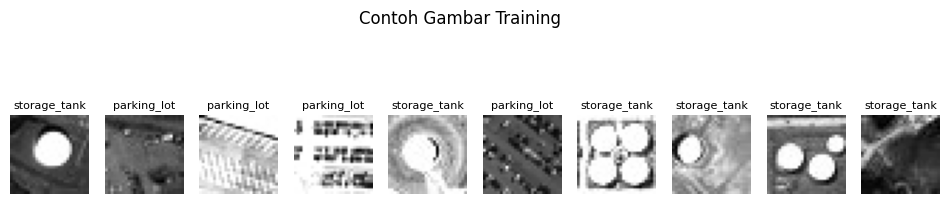

In [6]:
def show_sample_images(X, labels, title, n=10):
    plt.figure(figsize=(12, 3))
    for i in range(n):
        plt.subplot(1, n, i + 1)
        plt.imshow(X[i].squeeze(), cmap="gray")
        plt.title(labels[i], fontsize=8)
        plt.axis("off")
    plt.suptitle(title)
    plt.show()


show_sample_images(X_train, y_train_label, "Contoh Gambar Training", n=10)

## 8. Membuat TensorFlow Dataset

Autoencoder dilatih dengan pasangan (X, X) karena target output adalah gambar input itu sendiri.

In [7]:
train_dataset = tf.data.Dataset.from_tensor_slices((X_train, X_train))
train_dataset = train_dataset.shuffle(1000, seed=SEED).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

val_dataset = tf.data.Dataset.from_tensor_slices((X_val, X_val))
val_dataset = val_dataset.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

test_dataset = tf.data.Dataset.from_tensor_slices((X_test, X_test))
test_dataset = test_dataset.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

I0000 00:00:1782287912.810528      58 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1782287912.816387      58 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


## 9. Baseline Autoencoder

Baseline autoencoder mengikuti arsitektur pada soal:

Input 28x28x1 -> Conv2D + ReLU -> MaxPooling -> Flatten -> Dense 128 (latent) -> Dense 6272 -> Reshape 14x14x32 -> UpSampling -> Conv2D + ReLU -> Conv2D + Sigmoid.

Latent berdimensi 128 adalah hasil dimension reduction dari citra awal 784 dimensi.

In [8]:
def build_baseline_autoencoder():
    input_img = layers.Input(shape=(28, 28, 1), name="input_image")

    # Encoder
    x = layers.Conv2D(32, (3, 3), activation="relu", padding="same", name="encoder_conv")(input_img)
    x = layers.MaxPooling2D((2, 2), padding="same", name="encoder_maxpool")(x)
    x = layers.Flatten(name="flatten")(x)
    latent = layers.Dense(LATENT_DIM, activation="relu", name="latent_128")(x)

    # Decoder
    x = layers.Dense(14 * 14 * 32, activation="relu", name="decoder_dense")(latent)
    x = layers.Reshape((14, 14, 32), name="decoder_reshape")(x)
    x = layers.UpSampling2D((2, 2), name="decoder_upsampling")(x)
    x = layers.Conv2D(32, (3, 3), activation="relu", padding="same", name="decoder_conv")(x)
    decoded = layers.Conv2D(1, (3, 3), activation="sigmoid", padding="same", name="output_image")(x)

    autoencoder = models.Model(input_img, decoded, name="Baseline_Autoencoder")
    autoencoder.compile(optimizer=Adam(learning_rate=0.001), loss="mse")
    return autoencoder


baseline_ae = build_baseline_autoencoder()
baseline_ae.summary()

Model: "Baseline_Autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_image (InputLayer)        │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder_conv (Conv2D)           │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder_maxpool (MaxPooling2D)  │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ latent_128 (Dense)              │ (None, 128)            │       802,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder_dense (Dense)           │ (None, 6272)           │       809,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder_reshape (Reshape)       │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder_upsampling              │ (None, 28, 28, 32)     │             0 │
│ (UpSampling2D)                  │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder_conv (Conv2D)           │ (None, 28, 28, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_image (Conv2D)           │ (None, 28, 28, 1)      │           289 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,621,889 (6.19 MB)

 Trainable params: 1,621,889 (6.19 MB)

 Non-trainable params: 0 (0.00 B)

## 10. Training Baseline Autoencoder

Baseline dilatih dengan callback EarlyStopping dan ReduceLROnPlateau.

In [9]:
baseline_callbacks = [
    EarlyStopping(monitor="val_loss", patience=8, restore_best_weights=True),
    ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=4, min_lr=1e-6)
]

baseline_history = baseline_ae.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=40,
    callbacks=baseline_callbacks,
    verbose=1
)

Epoch 1/40


I0000 00:00:1782287916.881259     131 service.cc:152] XLA service 0x7ccf6400b030 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1782287916.881291     131 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1782287916.881294     131 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1782287917.215432     131 cuda_dnn.cc:529] Loaded cuDNN version 91002


 39/201 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0745

I0000 00:00:1782287919.669540     131 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


201/201 ━━━━━━━━━━━━━━━━━━━━ 8s 17ms/step - loss: 0.0406 - val_loss: 0.0263 - learning_rate: 0.0010
Epoch 2/40
201/201 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0232 - val_loss: 0.0220 - learning_rate: 0.0010
Epoch 3/40
201/201 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0198 - val_loss: 0.0193 - learning_rate: 0.0010
Epoch 4/40
201/201 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0182 - val_loss: 0.0184 - learning_rate: 0.0010
Epoch 5/40
201/201 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0174 - val_loss: 0.0179 - learning_rate: 0.0010
Epoch 6/40
201/201 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0170 - val_loss: 0.0175 - learning_rate: 0.0010
Epoch 7/40
201/201 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0167 - val_loss: 0.0174 - learning_rate: 0.0010
Epoch 8/40
201/201 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0166 - val_loss: 0.0176 - learning_rate: 0.0010
Epoch 9/40
201/201 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0164 - val_loss: 0.0172 - learning_rate: 0.0010
Epoch 10/40
201/201 

## 11. Visualisasi Training Loss Baseline

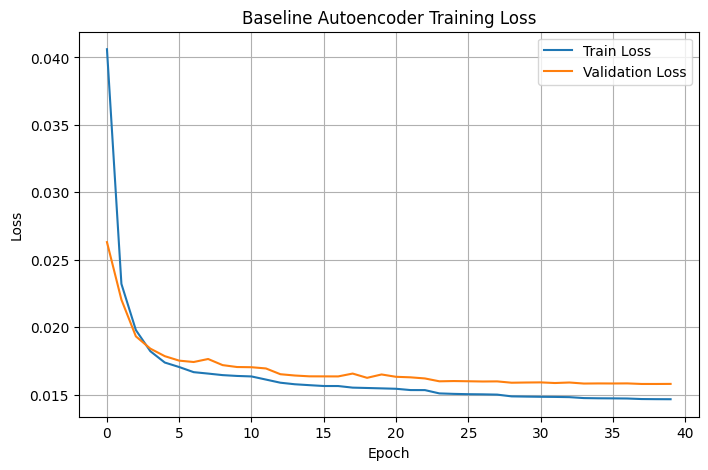

In [10]:
def plot_history(history, title):
    plt.figure(figsize=(8, 5))
    plt.plot(history.history["loss"], label="Train Loss")
    plt.plot(history.history["val_loss"], label="Validation Loss")
    plt.title(title)
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid(True)
    plt.show()


plot_history(baseline_history, "Baseline Autoencoder Training Loss")

## 12. Evaluasi Menggunakan SSIM

SSIM mengukur kemiripan struktur gambar asli dan hasil rekonstruksi. Semakin tinggi SSIM, semakin mirip hasilnya.

In [11]:
def calculate_mean_ssim(original_images, reconstructed_images):
    original_images = tf.convert_to_tensor(original_images, dtype=tf.float32)
    reconstructed_images = tf.convert_to_tensor(reconstructed_images, dtype=tf.float32)
    ssim_values = tf.image.ssim(original_images, reconstructed_images, max_val=1.0)
    return float(tf.reduce_mean(ssim_values).numpy())


def evaluate_autoencoder(model, X_test, model_name):
    reconstructed = model.predict(X_test, verbose=0)
    mean_ssim = calculate_mean_ssim(X_test, reconstructed)
    test_loss = model.evaluate(X_test, X_test, verbose=0)
    print(model_name)
    print("Test Loss :", test_loss)
    print("Mean SSIM :", mean_ssim)
    return {"Model": model_name, "Test Loss": test_loss, "Mean SSIM": mean_ssim}, reconstructed


baseline_result, baseline_reconstructed = evaluate_autoencoder(
    baseline_ae,
    X_test,
    "Baseline Autoencoder"
)

Baseline Autoencoder
Test Loss : 0.015109063126146793
Mean SSIM : 0.4692760705947876


## 13. Visualisasi Rekonstruksi Baseline

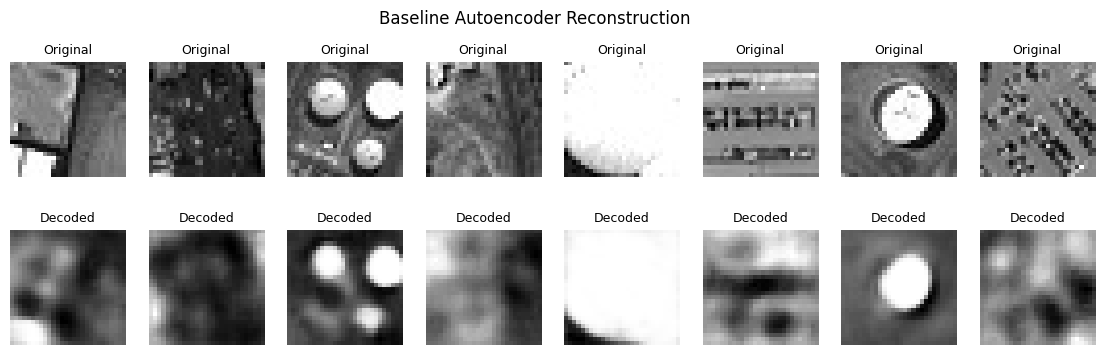

In [12]:
def show_reconstruction(original, reconstructed, title, n=8):
    plt.figure(figsize=(14, 4))
    for i in range(n):
        plt.subplot(2, n, i + 1)
        plt.imshow(original[i].squeeze(), cmap="gray")
        plt.title("Original", fontsize=9)
        plt.axis("off")

        plt.subplot(2, n, i + 1 + n)
        plt.imshow(reconstructed[i].squeeze(), cmap="gray")
        plt.title("Decoded", fontsize=9)
        plt.axis("off")
    plt.suptitle(title)
    plt.show()


show_reconstruction(X_test, baseline_reconstructed, "Baseline Autoencoder Reconstruction", n=8)

## 14. Modified Autoencoder

Modified autoencoder dibuat untuk meningkatkan kualitas rekonstruksi, dengan:
1. Menambah convolutional block kedua pada encoder
2. Menambah BatchNormalization
3. Menambah Dropout
4. Decoder bertahap dari 7x7 ke 14x14 lalu 28x28
5. Latent tetap 128 agar perbandingan dengan baseline adil

In [13]:
def build_modified_autoencoder(learning_rate=0.001, dropout_rate=0.10, filters_1=32, filters_2=64):
    input_img = layers.Input(shape=(28, 28, 1), name="input_image")

    # Encoder
    x = layers.Conv2D(filters_1, (3, 3), activation="relu", padding="same")(input_img)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D((2, 2), padding="same")(x)   # 14x14

    x = layers.Conv2D(filters_2, (3, 3), activation="relu", padding="same")(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D((2, 2), padding="same")(x)   # 7x7

    x = layers.Flatten()(x)
    x = layers.Dense(256, activation="relu")(x)
    x = layers.Dropout(dropout_rate)(x)
    latent = layers.Dense(LATENT_DIM, activation="relu", name="latent_128")(x)

    # Decoder
    x = layers.Dense(7 * 7 * filters_2, activation="relu")(latent)
    x = layers.Reshape((7, 7, filters_2))(x)

    x = layers.UpSampling2D((2, 2))(x)                   # 14x14
    x = layers.Conv2D(filters_2, (3, 3), activation="relu", padding="same")(x)
    x = layers.BatchNormalization()(x)

    x = layers.UpSampling2D((2, 2))(x)                   # 28x28
    x = layers.Conv2D(filters_1, (3, 3), activation="relu", padding="same")(x)
    x = layers.BatchNormalization()(x)

    decoded = layers.Conv2D(1, (3, 3), activation="sigmoid", padding="same", name="output_image")(x)

    autoencoder = models.Model(input_img, decoded, name="Modified_Autoencoder")
    autoencoder.compile(optimizer=Adam(learning_rate=learning_rate), loss="mse")
    return autoencoder

## 15. Hyperparameter Tuning Sederhana

Beberapa kombinasi learning rate, dropout rate, dan jumlah filter dicoba. Model terbaik dipilih berdasarkan SSIM pada validation set.

In [14]:
tuning_configs = [
    {"learning_rate": 0.001, "dropout_rate": 0.10, "filters_1": 32, "filters_2": 64},
    {"learning_rate": 0.0005, "dropout_rate": 0.10, "filters_1": 32, "filters_2": 64},
    {"learning_rate": 0.001, "dropout_rate": 0.20, "filters_1": 32, "filters_2": 64},
    {"learning_rate": 0.0005, "dropout_rate": 0.20, "filters_1": 64, "filters_2": 128}
]

tuning_results = []

for i, config in enumerate(tuning_configs):
    print("=" * 70)
    print(f"Tuning Experiment {i + 1}")
    print(config)
    print("=" * 70)

    model = build_modified_autoencoder(**config)
    callbacks = [EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True)]

    history = model.fit(
        train_dataset,
        validation_data=val_dataset,
        epochs=15,
        callbacks=callbacks,
        verbose=1
    )

    reconstructed_val = model.predict(X_val, verbose=0)
    val_ssim = calculate_mean_ssim(X_val, reconstructed_val)

    tuning_results.append({
        **config,
        "val_loss": min(history.history["val_loss"]),
        "val_ssim": val_ssim,
        "model": model
    })

    print("Validation SSIM:", val_ssim)


tuning_df = pd.DataFrame([{k: v for k, v in result.items() if k != "model"} for result in tuning_results])
display(tuning_df.sort_values("val_ssim", ascending=False))

Tuning Experiment 1
{'learning_rate': 0.001, 'dropout_rate': 0.1, 'filters_1': 32, 'filters_2': 64}
Epoch 1/15
201/201 ━━━━━━━━━━━━━━━━━━━━ 14s 33ms/step - loss: 0.0281 - val_loss: 0.0836
Epoch 2/15
201/201 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.0198 - val_loss: 0.0308
Epoch 3/15
201/201 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.0180 - val_loss: 0.0182
Epoch 4/15
201/201 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.0172 - val_loss: 0.0158
Epoch 5/15
201/201 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.0163 - val_loss: 0.0155
Epoch 6/15
201/201 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.0158 - val_loss: 0.0148
Epoch 7/15
201/201 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.0156 - val_loss: 0.0151
Epoch 8/15
201/201 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.0153 - val_loss: 0.0149
Epoch 9/15
201/201 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.0149 - val_loss: 0.0149
Epoch 10/15
201/201 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.0148 - val_loss: 0.0145
Epoch 11/15
201/201 ━━━━━━━━━━━━━━━━━

,learning_rate,dropout_rate,filters_1,filters_2,val_loss,val_ssim
1,0.0005,0.1,32,64,0.012884,0.534291
0,0.0010,0.1,32,64,0.013175,0.526401
3,0.0005,0.2,64,128,0.013577,0.516035
2,0.0010,0.2,32,64,0.014037,0.506303


## 16. Training Final Modified Autoencoder

Konfigurasi terbaik dari tuning dipakai untuk melatih final modified autoencoder.

In [15]:
best_result = sorted(tuning_results, key=lambda x: x["val_ssim"], reverse=True)[0]

best_config = {
    "learning_rate": best_result["learning_rate"],
    "dropout_rate": best_result["dropout_rate"],
    "filters_1": best_result["filters_1"],
    "filters_2": best_result["filters_2"]
}

print("Best Config:")
print(best_config)

modified_ae = build_modified_autoencoder(**best_config)
modified_ae.summary()

modified_callbacks = [
    EarlyStopping(monitor="val_loss", patience=10, restore_best_weights=True),
    ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=5, min_lr=1e-6)
]

modified_history = modified_ae.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=50,
    callbacks=modified_callbacks,
    verbose=1
)

Best Config:
{'learning_rate': 0.0005, 'dropout_rate': 0.1, 'filters_1': 32, 'filters_2': 64}


Model: "Modified_Autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_image (InputLayer)        │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_16 (Conv2D)              │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_16          │ (None, 28, 28, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_17 (Conv2D)              │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_17          │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 3136)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 256)            │       803,072 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ latent_128 (Dense)              │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 3136)           │       404,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape_4 (Reshape)             │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_8 (UpSampling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_18 (Conv2D)              │ (None, 14, 14, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_18          │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_9 (UpSampling2D)  │ (None, 28, 28, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_19 (Conv2D)              │ (None, 28, 28, 32)     │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_19          │ (None, 28, 28, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_image (Conv2D)           │ (None, 28, 28, 1)      │           289 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,315,777 (5.02 MB)

 Trainable params: 1,315,393 (5.02 MB)

 Non-trainable params: 384 (1.50 KB)

Epoch 1/50
201/201 ━━━━━━━━━━━━━━━━━━━━ 12s 29ms/step - loss: 0.0306 - val_loss: 0.0672 - learning_rate: 5.0000e-04
Epoch 2/50
201/201 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.0206 - val_loss: 0.0307 - learning_rate: 5.0000e-04
Epoch 3/50
201/201 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.0184 - val_loss: 0.0171 - learning_rate: 5.0000e-04
Epoch 4/50
201/201 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.0169 - val_loss: 0.0157 - learning_rate: 5.0000e-04
Epoch 5/50
201/201 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.0165 - val_loss: 0.0173 - learning_rate: 5.0000e-04
Epoch 6/50
201/201 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.0160 - val_loss: 0.0146 - learning_rate: 5.0000e-04
Epoch 7/50
201/201 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.0156 - val_loss: 0.0143 - learning_rate: 5.0000e-04
Epoch 8/50
201/201 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.0154 - val_loss: 0.0141 - learning_rate: 5.0000e-04
Epoch 9/50
201/201 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.0149 - val_loss: 0.0144 

## 17. Visualisasi Training Loss Modified Autoencoder

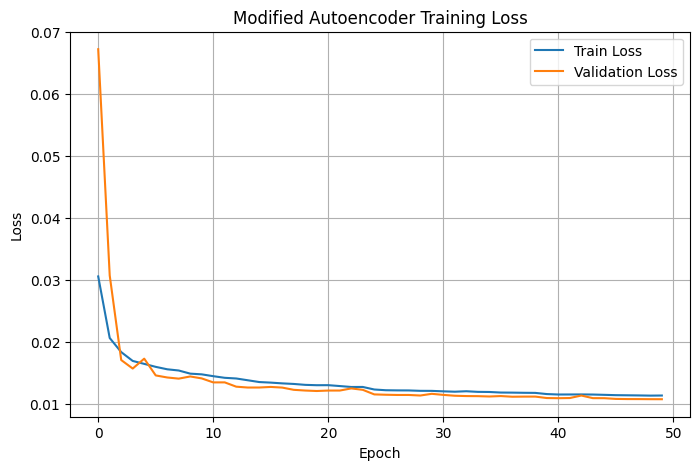

In [16]:
plot_history(modified_history, "Modified Autoencoder Training Loss")

## 18. Evaluasi Modified Autoencoder pada Test Set

In [17]:
modified_result, modified_reconstructed = evaluate_autoencoder(
    modified_ae,
    X_test,
    "Modified Autoencoder"
)

Modified Autoencoder
Test Loss : 0.010328841395676136
Mean SSIM : 0.5901753306388855


## 19. Visualisasi Rekonstruksi Modified Autoencoder

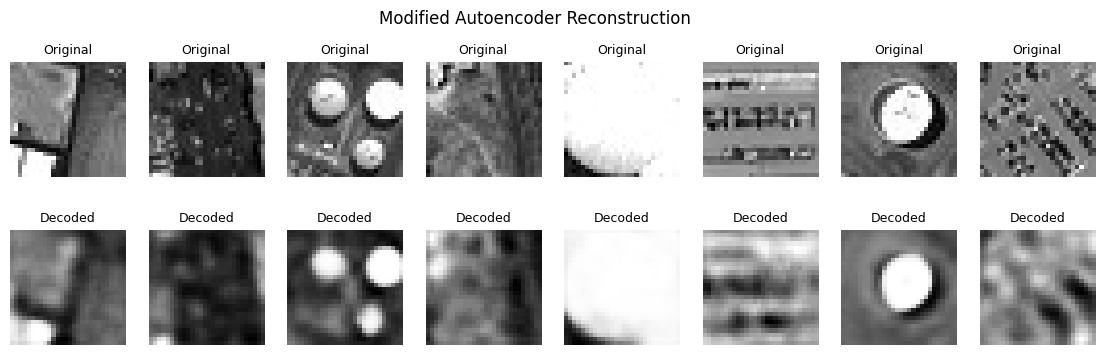

In [18]:
show_reconstruction(X_test, modified_reconstructed, "Modified Autoencoder Reconstruction", n=8)

## 20. Perbandingan Baseline vs Modified Autoencoder

Model terbaik dipilih berdasarkan Mean SSIM pada test set. SSIM lebih tinggi berarti rekonstruksi lebih baik.

In [19]:
results_df = pd.DataFrame([baseline_result, modified_result])
display(results_df)

best_model = results_df.sort_values("Mean SSIM", ascending=False).iloc[0]

print("Model terbaik berdasarkan SSIM:")
print(best_model["Model"])
print("Mean SSIM:", best_model["Mean SSIM"])

,Model,Test Loss,Mean SSIM
0,Baseline Autoencoder,0.015109,0.469276
1,Modified Autoencoder,0.010329,0.590175


Model terbaik berdasarkan SSIM:
Modified Autoencoder
Mean SSIM: 0.5901753306388855


## 21. Visualisasi Perbandingan Original, Baseline, dan Modified

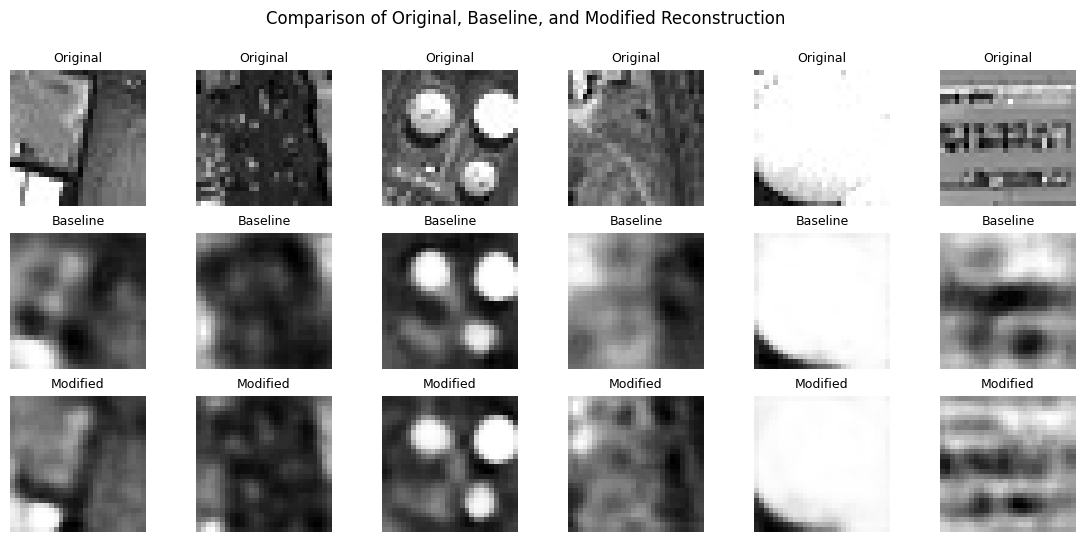

In [20]:
def compare_reconstructions(original, baseline_rec, modified_rec, n=6):
    plt.figure(figsize=(14, 6))

    for i in range(n):
        plt.subplot(3, n, i + 1)
        plt.imshow(original[i].squeeze(), cmap="gray")
        plt.title("Original", fontsize=9)
        plt.axis("off")

        plt.subplot(3, n, i + 1 + n)
        plt.imshow(baseline_rec[i].squeeze(), cmap="gray")
        plt.title("Baseline", fontsize=9)
        plt.axis("off")

        plt.subplot(3, n, i + 1 + 2*n)
        plt.imshow(modified_rec[i].squeeze(), cmap="gray")
        plt.title("Modified", fontsize=9)
        plt.axis("off")

    plt.suptitle("Comparison of Original, Baseline, and Modified Reconstruction")
    plt.show()


compare_reconstructions(X_test, baseline_reconstructed, modified_reconstructed, n=6)

## 22. Analisis Hasil

Dataset yang dipakai adalah dua kelas Overhead-MNIST, yaitu storage_tank dan parking_lot, sesuai pembagian NIM genap dan laki-laki. Gambar diambil dari folder train dan test, lalu digabung dan dibagi ulang menjadi 80% train, 10% validation, dan 10% test.

Semua gambar diubah ke grayscale 28x28 dan di-scaling ke 0-1. Scaling ini penting karena output decoder memakai sigmoid yang menghasilkan nilai 0-1.

Baseline autoencoder mengikuti arsitektur soal, mengubah citra 784 dimensi menjadi latent 128 lalu merekonstruksinya kembali. Modified autoencoder menambah convolutional block, BatchNormalization, Dropout, decoder bertahap, dan tuning hyperparameter.

Hasilnya, modified autoencoder lebih baik dari baseline: Mean SSIM naik dari 0.469 ke 0.590 dan test loss turun dari 0.0151 ke 0.0103. Jadi modifikasi dan tuning berhasil meningkatkan kualitas rekonstruksi. Alasannya: convolutional block kedua menangkap fitur lebih kaya, BatchNormalization membuat training lebih stabil, decoder bertahap merekonstruksi detail lebih halus, Dropout mengurangi overfitting, dan tuning memilih konfigurasi terbaik berdasarkan SSIM validation.

## 23. Kesimpulan

Eksperimen ini melakukan dimension reduction dengan autoencoder pada dua kelas Overhead-MNIST (storage_tank dan parking_lot). Citra 784 dimensi direduksi menjadi latent 128 lalu direkonstruksi kembali.

Baseline mengikuti arsitektur soal, dan modified ditambah convolutional block, BatchNormalization, Dropout, decoder bertahap, serta tuning hyperparameter. Berdasarkan SSIM pada test set, modified autoencoder menjadi yang terbaik dengan SSIM 0.590 dibanding 0.469 pada baseline.